# LAB 3: Linear Transformation and Inverse


# First: you should run this cell

In [1]:
# Make all numpy available via shorter 'np' prefix
import numpy as np
# Make all sympy available via shorter 'sym' prefix
import sympy as sym

import math


#import plotter
import matplotlib.pyplot as plt


def plot2d(H):
    x = H[0,:]
    y = H[1,:]
    plt.plot(x, y, 'ro', x, y, 'g-')
    plt.axis([-10, 10, -10, 10])
    plt.grid()

# Question 1: Geometry and Matrices

#### This question uses python to illustrate the geometric meaning of some special types of matrices.at next cell type:
- `plot2d(H)`

H = 
 [[-6 -6 -7  0  7  6  6 -3 -3  0  0 -6]
 [-7  2  1  8  1  2 -7 -7 -2 -2 -7 -7]]


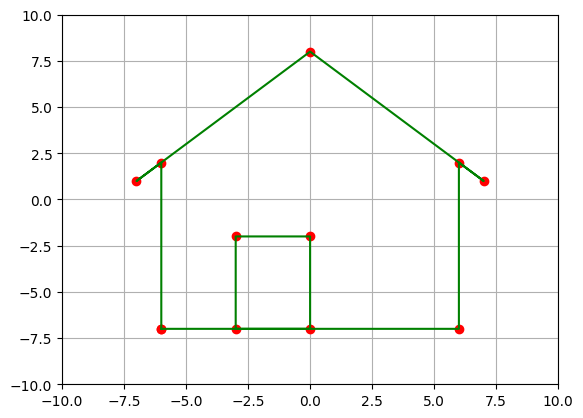

In [2]:
H = np.array([[-6,-6,-7, 0, 7, 6, 6,-3,-3, 0, 0,-6],[-7,2,1,8,1,2,-7,-7,-2,-2,-7,-7 ]])
print('H = \n', H)
plot2d(H)

A graphics window should open and display a crude drawing of a house. The matrix H contains the coordinates
of the endpoints of the line segments making up the drawing.

#### (a) Rotations: Generate a matrix Q and Let Q act on the house by plot2d(Q*H):

- `t = math.pi / 6`
- `Q = np.array([[math.cos(t), -math.sin(t)], [math.sin(t), math.cos(t)]])`
- Caculate `np.linalg.det(Q)`

##### Repeat this process with t = - pi/3 and answer (i) and (ii) in this case. Print the graph with the three house images on the same figure.

Q=[[ 0.8660254 -0.5      ]
 [ 0.5        0.8660254]]
det(q)=1.0
Q=[[ 0.8660254  0.5      ]
 [-0.5        0.8660254]]
det(q)=1.0


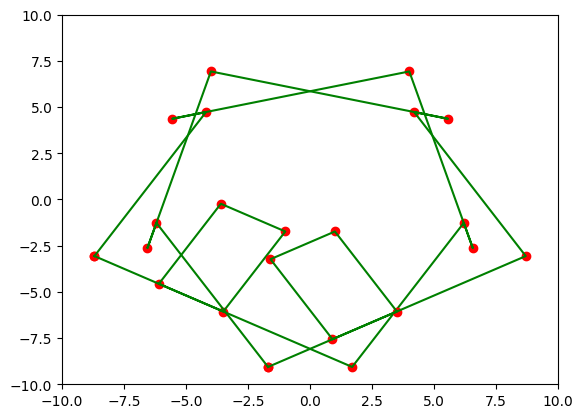

In [8]:
#type your code here:
t=math.pi/6
Q=np.array([[math.cos(t),-math.sin(t)],[math.sin(t),math.cos(t)]])

Q_=np.array([[math.cos(-t),-math.sin(-t)],[math.sin(-t),math.cos(-t)]])
print(f"Q={Q}")
print(f"det(q)={np.linalg.det(Q)}")
print(f"Q={Q_}")
print(f"det(q)={np.linalg.det(Q_)}")
v=np.matmul(Q,H)
u=np.matmul(Q_,H)
plot2d(u)
plot2d(v)

#### (b) Dilations: Clear the graphics window and generate a new plot of the house as above. Generate a matrix D by
- `r = .9`
- `D = np.array([[r, 0], [0, 1 / r]])`
- Caculate `np.linalg.det(D)`

Let D act on the house by `plot2d(D*H)`.


#### Repeat this process with r = .8 and answer (i) and (ii) in this case. Print the graph with the three house images on the same figure.

D=[[0.8  0.  ]
 [0.   1.25]]
det(D)=1.0
S=[[0.9        0.        ]
 [0.         1.11111111]]
det(S)=1.0


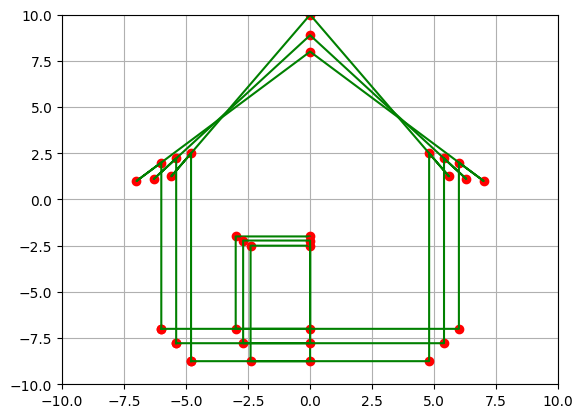

In [10]:
from numpy.ma.core import product
#type your code here:
r=0.8
y=0.9
D=np.array([[r,0],[0,1/r]])
print(f"D={D}")
print(f"det(D)={np.linalg.det(D)}")
S=np.array([[y,0],[0,1/y]])
print(f"S={S}")
print(f"det(S)={np.linalg.det(S)}")
product=np.matmul(D,H)
product_=np.matmul(S,H)
plot2d(H)
plot2d(product)
plot2d(product_)

#### (c) Shearing Transformations: Clear the graphics window and generate a new plot of the house as above. Generate a matrix T by

- `t = 1/2`
- `T = np.array([[1, t], [0, 1]])`
- - Caculate `np.linalg.det(T)`

Now let T act on the house by `plot2d(T*H)`.

#### Repeat this process with t = - 1/2 and answer (i) and (ii) in this case. Print the graph with the three house images on the same figure

D=[[1.  0.5]
 [0.  1. ]]
det(D)=1.0
S=[[ 1.  -0.5]
 [ 0.   1. ]]
det(S)=1.0


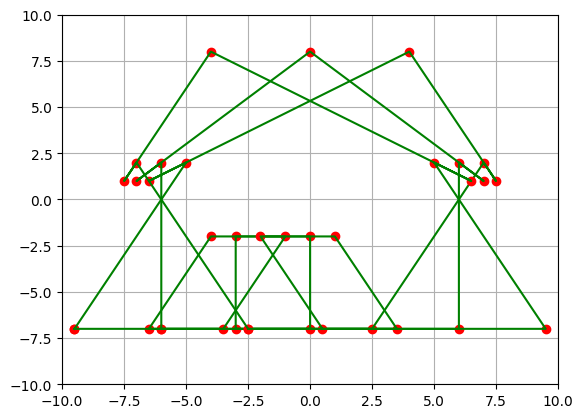

In [11]:
from numpy.ma.core import product
#type your code here:
r=0.5
y=-0.5
D=np.array([[1,r],[0,1]])
print(f"D={D}")
print(f"det(D)={np.linalg.det(D)}")
S=np.array([[1,y],[0,1]])
print(f"S={S}")
print(f"det(S)={np.linalg.det(S)}")
product=np.matmul(D,H)
product_=np.matmul(S,H)
plot2d(H)
plot2d(product)
plot2d(product_)

# Question 2: Solving $Ax = b$

Implementing a function to Solve $Ax = b$ using the inverse of $A$ without using `numpy.linalg.inv`

### Step 1:

- Define a function that checks that A and b have correct dimensions (number of rows of $A$ = number of rows of $b$). `check_dimensions(A, b)`. Return a `boolean`.

In [12]:
def check_dimensions(A, b):
    ##########type your code here#############
    return A.shape[0]==b.shape[0]

    ##########################################

### Step 2:
- Define a function that takes a matrix and check if it is a squared matrix. `check_squared(A)`. Return a `boolean`.

In [13]:
def check_squared(A):
    ##########type your code here#############
    return A.shape[0]==A.shape[1]

    ##########################################

### Step 3:
- Define a function that takes a matrix and the indices of a column and a row and returns the corresponding minor coefficient. `minor_coef(A, i, j)`.

In [68]:
def minor_coef(A, i, j):
    ##########type your code here#############
    check_dimensions(A,A)
    check_squared(A)
    return np.delete(np.delete(A,j,1),i,0)


    ##########################################

In [75]:
k=np.array([[1,2],
          [5,6]]) # Changed k to a square matrix
minors(k)

array([[6., 5.],
       [2., 1.]])

### Step 4:
- Define a function that takes a matrix and gives its matrix of minors. `minors(A)`.

In [76]:
def minors(A):
    M = np.zeros(A.shape)
    ##########type your code here#############
    for i in range(A.shape[0]):
      for j in range(A.shape[1]):
        M[i,j]=np.linalg.det(minor_coef(A,i,j))


    ##########################################
    return M

In [79]:
k=np.array([[1,2,8],
          [5,6,9],
            [2,6,8]])
minors(k)

array([[ -6.,  22.,  18.],
       [-32.,  -8.,   2.],
       [-30., -31.,  -4.]])

### Step 5:
- Define a function that takes matrix $A$ gives a matrix of cofactors. `cofactors(A)`

In [80]:
def cofactors(A):
    M = minors(A)
    C = np.zeros(M.shape)
    ##########type your code here#############
    for i in range(M.shape[0]):
      for j in range(M.shape[1]):
        C[i,j]=(-1)**((i+j))*M[i,j]
    ##########################################
    return C

### Step 6:
- Define a function that takes a matrix and gives its transpose. `transpose(A)`

In [81]:
def transpose(A):
    A_T =A.T
    ##########type your code here#############
    print(A_T)

    ##########################################
    return A_T


### Step 7:
- Code a function that gives the inverse of a matrix. `inverse(A)`.
    - Check first if the matrix is a square matrix. If not raise an error.
    - Check if the matrix is invertible. If not raise an error.

In [82]:
def inverse(A):
    if not check_squared(A):
        raise Exception('A is not a square matrix.')
    d = np.linalg.det(A)
    if abs(d) < 10 ** -10:
        raise Exception('Singular matrix: A is not invertible.')
    ##########type your code here#############
    return (1/d)*transpose(cofactors(A))

    ##########################################


### Step 8:
- Define a function that takes a matrix $A$, a vector $b$ and gives the vector $x$ solution of $Ax = b$. `solve(A, b)`.
- Check dimension first if not raise an error.

In [89]:
def solve(A, b):
    if not check_dimensions(A, b):
        raise Exception('Inconsistent Dimensions.')
        ##########type your code here#############
    return inverse(A)@b
        ##########################################


        ##########################################

### Step 9:
- Use the function `solve` in the previous step to solve the following systems of linear equations:

1) $x + 2y = -1$; $3x + 4y = 1$

2) $3x - 2y + z = 7$; $x + z = 2$; $-2y - z = 3$

In [94]:
A=np.array([[1,2],[3,4]])
b=np.array([[-1],[1]])

C=np.array([[3,-2,1],[1,0,1],[0,-2,-1]])
D=np.array([[7],[2],[3]])

print(solve(A,b))
print(solve(C,D))

[[ 4. -2.]
 [-3.  1.]]
[[ 3.]
 [-2.]]
[[ 2. -4. -2.]
 [ 1. -3. -2.]
 [-2.  6.  2.]]
[[ 0. ]
 [-2.5]
 [ 2. ]]


### Step 10:
- Error testing: Run the following cells to test the erros.

In [95]:
A = np.array([[3, -2, 1],
              [1, 0, 1],
              [0, -2, -1]])

b = np.array([[7],
              [2]])

print('A =\n {}\n'.format(A))
print('b =\n {}\n'.format(b))

x = solve(A, b)

A =
 [[ 3 -2  1]
 [ 1  0  1]
 [ 0 -2 -1]]

b =
 [[7]
 [2]]



Exception: Inconsistent Dimensions.

In [92]:
A = np.array([[3, 1],
              [-2, 0],
              [1, 1]])

b = np.array([[7],
              [2],
              [3]])

print('A =\n {}\n'.format(A))
print('b =\n {}\n'.format(b))

x = solve(A, b)

A =
 [[ 3  1]
 [-2  0]
 [ 1  1]]

b =
 [[7]
 [2]
 [3]]



Exception: A is not a square matrix.

In [93]:
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

b = np.array([[7],
              [2],
              [3]])

print('A =\n {}\n'.format(A))
print('b =\n {}\n'.format(b))

x = solve(A, b)

A =
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

b =
 [[7]
 [2]
 [3]]



Exception: Singular matrix: A is not invertible.